# 15 — MACHINE LEARNING / SURROGATE MODELING

Random Forest ile fizik modelinin ürettiği ROC değerini tahmin etme..


In [1]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

path = "data/generated/TBM_X_Large_Design_Dataset_Feasible_v0_1.csv"
if not os.path.exists(path): raise FileNotFoundError("Run Notebook 13 first.")
df = pd.read_csv(path)


## Features and target

In [2]:
features = ["MTOW_kg","wing_area_m2","aspect_ratio","power_kW","cruise_speed_kt","cd0","oswald_efficiency","prop_efficiency"]
target = "ROC_ft_min"
data = df[features+[target]].dropna()
X, y = data[features], data[target]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.20,random_state=42)
print(X_train.shape, X_test.shape)


(1033, 8) (259, 8)


## Train model

In [3]:
model = RandomForestRegressor(n_estimators=250,max_depth=18,min_samples_leaf=3,random_state=42,n_jobs=-1)
model.fit(X_train,y_train); pred = model.predict(X_test)
metrics = pd.DataFrame({"metric":["MAE_ft_min","RMSE_ft_min","R2"],"value":[
    mean_absolute_error(y_test,pred),
    np.sqrt(mean_squared_error(y_test,pred)),
    r2_score(y_test,pred)]})
display(metrics)


,metric,value
0,MAE_ft_min,245.850814
1,RMSE_ft_min,300.866102
2,R2,0.896681


## Parity plot and residuals

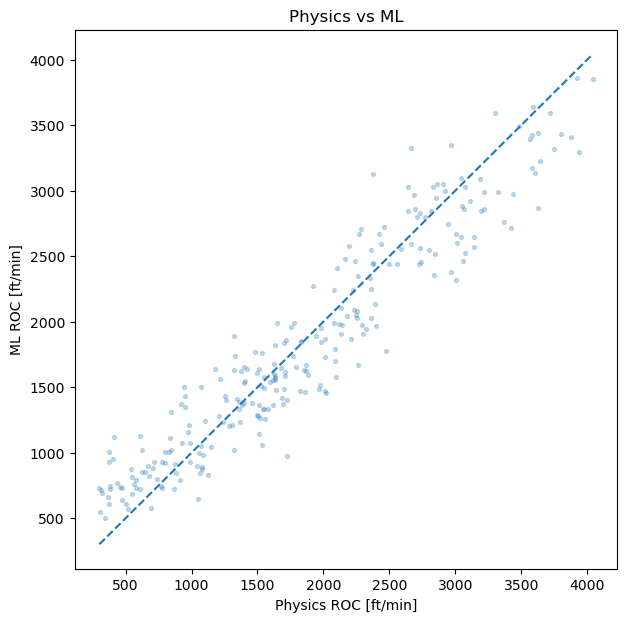

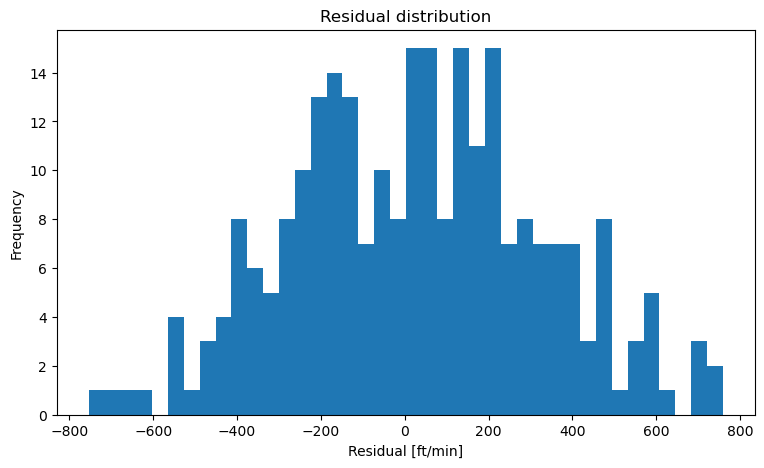

In [4]:
plt.figure(figsize=(7,7)); plt.scatter(y_test,pred,s=8,alpha=.25)
lo,hi=min(y_test.min(),pred.min()),max(y_test.max(),pred.max())
plt.plot([lo,hi],[lo,hi],"--"); plt.xlabel("Physics ROC [ft/min]"); plt.ylabel("ML ROC [ft/min]")
plt.title("Physics vs ML"); plt.show()

plt.figure(figsize=(9,5)); plt.hist(y_test-pred,bins=40)
plt.xlabel("Residual [ft/min]"); plt.ylabel("Frequency"); plt.title("Residual distribution"); plt.show()


## Feature importance

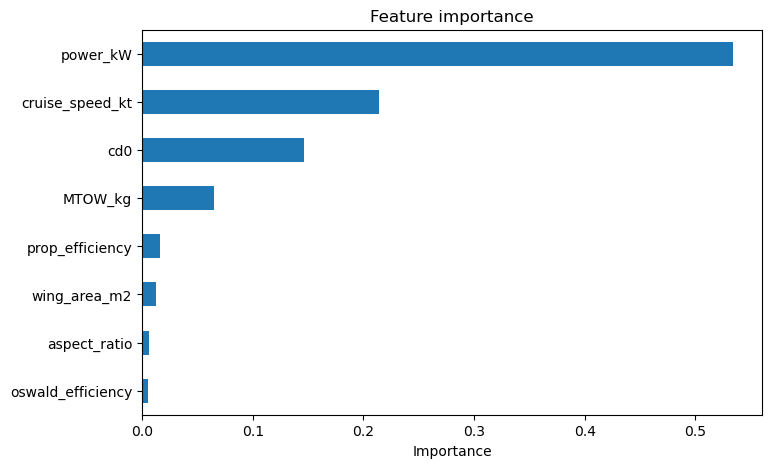

,importance
power_kW,0.533654
cruise_speed_kt,0.213816
cd0,0.146677
MTOW_kg,0.064982
prop_efficiency,0.016398
wing_area_m2,0.012997
aspect_ratio,0.005978
oswald_efficiency,0.005499


In [5]:
importance = pd.Series(model.feature_importances_,index=features).sort_values()
plt.figure(figsize=(8,5)); importance.plot(kind="barh"); plt.xlabel("Importance"); plt.title("Feature importance"); plt.show()
display(importance.sort_values(ascending=False).to_frame("importance"))


## Save model

In [6]:
import joblib
os.makedirs("outputs/ml",exist_ok=True)
joblib.dump(model,"outputs/ml/TBM_X_ROC_RandomForest_v0_1.joblib")
metrics.to_csv("outputs/ml/TBM_X_ROC_Model_Metrics_v0_1.csv",index=False)
importance.to_frame("importance").to_csv("outputs/ml/TBM_X_ROC_Feature_Importance_v0_1.csv")
print("Model and metrics saved.")


Model and metrics saved.


## Engineering assessment

Surrogate model yalnızca eğitim aldığı tasarım uzayı içinde kullanılmalıdır. Extrapolation riski vardır. Sonraki adımlar: cross-validation, UQ ve fiziksel kısıtların uygulanmasıdır.